# Thermostat Hybrid Automaton

This is a demo of the implementation of a simple 2 state hybrid automaton for a thermostat: 
states: Heating, Idle
continous state: temperature
continous auxielary states: None
auxielary context: None

transitions: heating to idea if T >= Tmax




In [6]:
import os 
import sys

sys.path.append(
    '/home/ryan/hybrid-automaton/src/hybrid_automaton'
)

from hybrid_automaton import HybridState
from hybrid_automaton import HybridTransition
import numpy as np

# initialize configuration values
k_heat = 1.0
k_cool = 0.5

t_max = 25
t_min = 20

# define initial continous state
init_temp = 20.0
continous_state = init_temp

# create flow functions
def heating_flow(x, u, ctx, dt):
    """Derivative of temperature in Heating mode"""
    dTdt = k_heat
    return dTdt

def idle_flow(x, u, ctx, dt):
    """Derivative of temperature in Idle mode"""
    dTdt = -k_cool
    return dTdt


## create states

In [7]:
heating_state = HybridState(
    name='heating',
    value=0,
    initial=True,
    flow=heating_flow,
)
idle_state = HybridState(
    name='idle',
    value=1,
    flow=idle_flow
)

print (heating_state)
print (idle_state)

State 'heating' (value=0, initial)
  flow: heating_flow
  invariants: [None]
  transitions: [None]
State 'idle' (value=1, normal)
  flow: idle_flow
  invariants: [None]
  transitions: [None]


## create transitions

In [8]:
heating_state.add_transition(
    HybridTransition(
        'heating_to_idle',
        value=0,
        to_state=idle_state,
        guards=[
            lambda x, u, ctx, dt: x > t_max
        ]
    )
)
idle_state.add_transition(
    HybridTransition(
        'idle_to_heating',
        value=1,
        to_state=heating_state,
        guards=[
            lambda x, u, ctx, dt: x < t_min
        ]
    )
)

## create the hybrid automaton

In [9]:
from hybrid_automaton import HybridAutomaton

ha = HybridAutomaton(
    name="thermostat",
    value=0,
    states=[heating_state, idle_state],
    real_time_mode=False
)

In [10]:
import asyncio

q_data = []
x_data = []
elapsed_time_active = []
elapsed_time_since_last_transition = []

async def print_data(): 
    await asyncio.sleep(0.05) # give some time for the automaton to start
    while True: 
        print(
            f"curent discrete state: {ha.q.name}\n",
            f"elapsed_time_active: {ha.elapsed_time_active}\n", 
            f"elapsed_time_since_last_transition: {ha.elapsed_time_since_last_transition}\n", 
            f"continous state: {ha.x}\n",
        )
        q_data.append(ha.q)
        x_data.append(ha.x)
        elapsed_time_active.append(ha.elapsed_time_active)
        elapsed_time_since_last_transition.append(ha.elapsed_time_since_last_transition)

        await asyncio.sleep(0.05)


t1 = asyncio.create_task(print_data())
t2 = asyncio.create_task(ha.evluation_loop_worker(continous_state))

try: 
    await asyncio.wait_for(
        asyncio.gather(t1, t2), timeout=60
    )
except asyncio.TimeoutError: 
    print ("1 minute elapsed, stopping tasks")
    t1.cancel()
    t1.cancel()



starting thermostat
curent discrete state: heating
 elapsed_time_active: 0.04164544199920783
 elapsed_time_since_last_transition: 0.0416508079997584
 continous state: 20.1

curent discrete state: heating
 elapsed_time_active: 0.09343068899943319
 elapsed_time_since_last_transition: 0.09345550600119168
 continous state: 20.200000000000003

curent discrete state: heating
 elapsed_time_active: 0.1467827809992741
 elapsed_time_since_last_transition: 0.14679086199976155
 continous state: 20.200000000000003

curent discrete state: heating
 elapsed_time_active: 0.19837628200002655
 elapsed_time_since_last_transition: 0.19839234000028227
 continous state: 20.300000000000004

curent discrete state: heating
 elapsed_time_active: 0.2509745919996931
 elapsed_time_since_last_transition: 0.2509829530008574
 continous state: 20.300000000000004

curent discrete state: heating
 elapsed_time_active: 0.3033041090002371
 elapsed_time_since_last_transition: 0.3033128300012322
 continous state: 20.400000000

/home/ryan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


TypeError: float() argument must be a string or a real number, not 'HybridState'

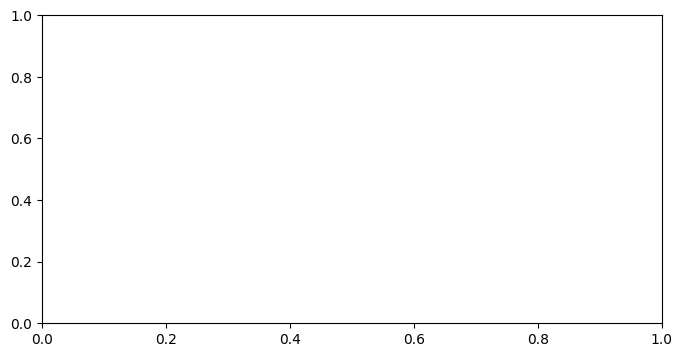

In [11]:
import matplotlib.pyplot as plt

# Safely filter out None values
q_data_clean = [x for x in q_data if x is not None]

# Basic plot
plt.figure(figsize=(8, 4))
plt.plot(q_data_clean, marker='o', linestyle='-', color='blue')
plt.title("q_data over time")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
print (idle_state)

State 'idle' (value=1, normal)
  flow: idle_flow
  invariants: [None]
  transitions: [idle_to_heating -> heating, guards=['<lambda>'], reset=None]
